In [1]:
# notebook to compare the activity predictions of dELS for PARM and MPAC #

In [1]:
# import packages #
import pandas as pd
import os
import matplotlib.pyplot as mpl
import matplotlib
import seaborn as sns
from scipy import stats
import numpy as np
from collections import Counter
import glob
from tqdm import tqdm

In [2]:
# open PARM predictions
path2k562 = '/projects/tewhey-lab/buttsj/Variant_Effects/revision_experiments/distal_cre_sat_mut/encode_cCRE_all/parm_preds/activity_preds/k562'
path2hepg2 = '/projects/tewhey-lab/buttsj/Variant_Effects/revision_experiments/distal_cre_sat_mut/encode_cCRE_all/parm_preds/activity_preds/hepg2'
all_parm_k562 = pd.concat([pd.read_csv(f'{path2k562}/{i}', sep = '\t') for i in [i for i in os.listdir(path2k562) if i.endswith('.tsv')]])
all_parm_hepg2 = pd.concat([pd.read_csv(f'{path2hepg2}/{i}', sep = '\t') for i in [i for i in os.listdir(path2hepg2) if i.endswith('.tsv')]])

In [3]:
all_parm_k562.head()

,sequence,header,prediction_K562
0,CTTGGCTAATTTTTTTTTTTTTTTTTTTTATAAAGACAGGGTCTCT...,chr1:221168997-221169268,0.001840
1,TGTAGTTGGAGGATTTGCAGTTTAAATAGCCGCAGCATTTCTCCAA...,chr1:221169535-221169879,0.133052
2,GGGTACTATTTTAGCATCAGGACTAATAAAATTAAAATCTCATACT...,chr1:221170233-221170525,0.000000
3,AGGTATATGATTGTGTTTGTATGAGCATGTACCTGAGTGGTATGTG...,chr1:221172891-221173234,0.063515
4,TGTCCAAGTCTCTAACAGCTCGTATGGAGTCAAAACCCATGATCTT...,chr1:221174369-221174581,0.000000


In [4]:
# open BED file of dELS for adding enhancer IDs
enhancer_bed = pd.read_csv('../processed_data/GRCh38-dELS-only.bed', sep = '\t', header = None)
# make a dictionary of position (chr:start-end) : enhancer ID pairs
enhancer_dict = dict(zip([f'{chrom}:{str(start)}-{str(end)}' for chrom, start, end in zip(enhancer_bed[0],
                                                                                          enhancer_bed[1],
                                                                                          enhancer_bed[2])],
                        enhancer_bed[4]))

In [5]:
# add enhancer id for merging with mpac predictions
all_parm_k562.loc[:,'id'] = [enhancer_dict.get(i) for i in all_parm_k562['header']]
all_parm_hepg2.loc[:,'id'] = [enhancer_dict.get(i) for i in all_parm_hepg2['header']]

In [6]:
# open mpac average predictions
all_mean_preds = pd.read_csv('../processed_data/all_dELS_sat_mut_groupby_mean.tsv',
                             sep = '\t')
print(len(all_mean_preds))

1432012


In [7]:
all_mean_preds[all_mean_preds['id'] == 'EH38E3390418']

,id,k562_ref_pred,k562_alt_pred,k562_skew_pred,hepg2_ref_pred,hepg2_alt_pred,hepg2_skew_pred,sknsh_ref_pred,sknsh_alt_pred,sknsh_skew_pred
226204,EH38E3390418,2.260034,2.181817,-0.078216,0.074743,0.085717,0.010974,0.210593,0.219879,0.009286


In [8]:
# merge predictions for plotting
k562_merged_preds = all_mean_preds.filter(['id', 'k562_ref_pred']).merge(all_parm_k562, on='id')
hepg2_merged_preds = all_mean_preds.filter(['id', 'hepg2_ref_pred']).merge(all_parm_hepg2, on='id')

In [9]:
print(len(k562_merged_preds))
print(len(hepg2_merged_preds))
# there are 15 fewer IDs in the merged predictions because there were 15 enhancers with ambiguous fasta bases
# the intervals are stored on Sumner in processed_data/dels_fasta_chunks/edited_fastas/dropped_enhancers.txt

1431997
1431997


In [10]:
# K562 #
k562_cCREs = pd.read_csv('../raw_data/ENCFF414OGC_ENCFF806YEZ_ENCFF849TDM_ENCFF736UDR_K562_cCRE.bed',
                        sep = '\t',
                        header = None)
k562_dELS = k562_cCREs[k562_cCREs[9] == 'dELS']
# HepG2 #
hepg2_cCREs = pd.read_csv('../raw_data/ENCFF546MZK_ENCFF732PJK_ENCFF795ONN_ENCFF357NFO_HepG2_cCRE.bed',
                          sep = '\t',
                          header = None)
hepg2_dELS = hepg2_cCREs[hepg2_cCREs[9] == 'dELS']

In [11]:
# make dictionary of cell type matched enhancers
k562_dELS_dict = dict(zip(k562_dELS[3], ['cell_type_matched' for i in range(len(k562_dELS))]))
hepg2_dELS_dict = dict(zip(hepg2_dELS[3], ['cell_type_matched' for i in range(len(hepg2_dELS))]))

In [12]:
len(k562_dELS)

35488

In [13]:
1431997 - 35488

1396509

In [14]:
len(hepg2_dELS)

29317

In [15]:
1431997 - 29317

1402680

In [16]:
# annotate merged predictions with cell type specificity information
k562_merged_preds.loc[:,'cCRE_type'] = [k562_dELS_dict.get(i) if i in k562_dELS_dict.keys() else 'cell_type_agnostic' for i in k562_merged_preds['id']]
hepg2_merged_preds.loc[:,'cCRE_type'] = [hepg2_dELS_dict.get(i) if i in hepg2_dELS_dict.keys() else 'cell_type_agnostic' for i in hepg2_merged_preds['id']]

In [17]:
# let's define a function to plot the comparisons we're interested in
# 1st panel:
# scatterplot of mpac vs. parm predictions colored by cCRE being cell type matched or agnostic
# 2nd panel:
# mpac 
# violin plot of activity comparing the differences in cell type matched and cell type agnostic
# 3rd panel:
# parm
# violin plot of activity comparing the differences in cell type matched and cell type agnostic
# 4th panel:
# mpac
# histogram of activity for cell type matched vs. agnostic
# 5th panel
# parm
# histogram of activity for cell type matched vs. agnostic

In [18]:
def dELS_mpac_parm_summary(merged_predictions,
                           cell_type,
                           cell_color,
                           outpath):
    # add an annotation for K562 zoomed plot
    if cell_type == 'K562':
        zoom = 'Zoomed'
    else:
        zoom = ''
    merged_predictions = merged_predictions.sort_values(by='cCRE_type')
    # filter for cell type matched predictions
    cell_matched_preds = merged_predictions[merged_predictions['cCRE_type'] == 'cell_type_matched']
    print(len(cell_matched_preds))
    # filter for only agnostic
    agnostic_preds = merged_predictions[merged_predictions['cCRE_type'] != 'cell_type_matched']
    # define column variables
    # mpac
    mpac_col = f'{cell_type.lower()}_ref_pred'
    # parm
    parm_col = f'prediction_{cell_type}'
    # define color palette
    color_palette = {'cell_type_matched' : cell_color,
                     'cell_type_agnostic' : 'gray'}
    
    ### get correlations ###
    # get the pearson correlation for all cCREs
    corr_all, p_all = stats.pearsonr(x=merged_predictions[mpac_col],
                                     y=merged_predictions[parm_col])
    corr_all_round = round(corr_all,2)
    # get the pearson correlation for cell type matched cCREs
    corr_matched, p_matched = stats.pearsonr(x=cell_matched_preds[mpac_col],
                                             y=cell_matched_preds[parm_col])
    corr_matched_round = round(corr_matched, 2)
    # get the pearson correlation for cell type agnostic cCREs
    corr_agnostic, p_agnostic = stats.pearsonr(x=agnostic_preds[mpac_col],
                                               y=agnostic_preds[parm_col])
    corr_agnostic_round = round(corr_agnostic, 2)

    ### calculate mann whitney-u's ###
    # mpac
    mpac_mannWhitney, mpac_mannWhitney_p = stats.mannwhitneyu(x=cell_matched_preds[mpac_col],
                                                              y=agnostic_preds[mpac_col],
                                                              alternative='greater')
    mpac_effectSize = mpac_mannWhitney / (len(cell_matched_preds) * len(agnostic_preds))
    # parm
    parm_mannWhitney, parm_mannWhitney_p = stats.mannwhitneyu(x=cell_matched_preds[parm_col],
                                                              y=agnostic_preds[parm_col],
                                                              alternative='greater')
    parm_effectSize = parm_mannWhitney / (len(cell_matched_preds) * len(agnostic_preds))
    # bootstrap difference between the two A-statistics
    def calculate_a_statistic(x, y):
        """Calculates the A-statistic (CLES) for two independent samples."""
        if len(x) == 0 or len(y) == 0:
            return np.nan
        u_statistic, _ = stats.mannwhitneyu(x, y, alternative='greater')
        return u_statistic / (len(x) * len(y))
    # Sub-sample ONCE to a manageable size before doing any bootstrapping.
    subset_size = 100000  # 100k is an excellent choice for 2M row data

    print(f"Sub-sampling full datasets down to {subset_size} rows each...")
    mpac_agnostic_sub = agnostic_preds[mpac_col].sample(n=min(len(agnostic_preds), subset_size), random_state=42)
    mpac_matched_sub = cell_matched_preds[mpac_col].sample(n=min(len(cell_matched_preds), subset_size), random_state=42)
    # ... repeat for your neuron data ...
    parm_agnostic_sub = agnostic_preds[parm_col].sample(n=min(len(agnostic_preds), subset_size), random_state=42)
    parm_matched_sub = cell_matched_preds[parm_col].sample(n=min(len(cell_matched_preds), subset_size), random_state=42)
    # Convert to NumPy for a little extra speed
    mpac_agn_np = mpac_agnostic_sub.to_numpy()
    mpac_mat_np = mpac_matched_sub.to_numpy()
    parm_agn_np = parm_agnostic_sub.to_numpy()
    parm_mat_np = parm_matched_sub.to_numpy()

    # --- NOW, PROCEED WITH THE BOOTSTRAP LOOP ---
    # Use 5000 iterations for a fast, initial result.
    n_bootstraps = 5000
    bootstrap_differences = []

    print(f"Running {n_bootstraps} fast bootstrap iterations...")

    for i in tqdm(range(n_bootstraps)):
        # Resample using the faster np.random.choice
        mpac_agn_sample = np.random.choice(mpac_agn_np, size=len(mpac_agn_np), replace=True)
        mpac_mat_sample = np.random.choice(mpac_mat_np, size=len(mpac_mat_np), replace=True)
        parm_agn_sample = np.random.choice(parm_agn_np, size=len(parm_agn_np), replace=True)
        parm_mat_sample = np.random.choice(parm_mat_np, size=len(parm_mat_np), replace=True)
        
        # Calculation remains the same
        a_stat_mpac = calculate_a_statistic(mpac_mat_sample, mpac_agn_sample)
        a_stat_parm = calculate_a_statistic(parm_mat_sample, parm_agn_sample)
        
        bootstrap_differences.append(a_stat_mpac - a_stat_parm)

    print("Bootstrap complete.")
    # --- 4. Calculate the confidence interval of the difference ---
    # Calculate the 95% confidence interval from the percentiles of the difference distribution
    confidence_interval = np.percentile(bootstrap_differences, [2.5, 97.5])

    # Also, calculate the observed difference on the original data
    observed_a_stat_mpac = calculate_a_statistic(cell_matched_preds[mpac_col], agnostic_preds[mpac_col])
    observed_a_stat_parm = calculate_a_statistic(cell_matched_preds[parm_col], agnostic_preds[parm_col])
    observed_difference = observed_a_stat_mpac - observed_a_stat_parm
    # --- 5. Interpret the results ---
    print("\n--- Results ---")
    print(f"Observed A-statistic (MPAC): {observed_a_stat_mpac:.3f}")
    print(f"Observed A-statistic (PARM): {observed_a_stat_parm:.3f}")
    print(f"Observed Difference (MPAC - PARM): {observed_difference:.3f}")
    print(f"95% Confidence Interval for the Difference: [{confidence_interval[0]:.3f}, {confidence_interval[1]:.3f}]")
    if confidence_interval[0] > 0 or confidence_interval[1] < 0:
        print("\nConclusion: The confidence interval does NOT contain 0.")
        print("This provides significant evidence that the effect sizes are different between the two models.")
    else:
        print("\nConclusion: The confidence interval contains 0.")
        print("We cannot conclude that there is a significant difference in effect sizes between the two models.")
        
    ### get to plotting ###
    f = mpl.figure(figsize = (12,1), dpi = 300)
    gs = f.add_gridspec(1,3)
    matplotlib.rcParams['pdf.fonttype'] = 42
    matplotlib.rcParams['ps.fonttype'] = 42
    # plot scatterplot #
    with sns.axes_style('white'):
        ax01 = f.add_subplot(gs[0,0])
        ax01.set(adjustable = 'box', aspect = 'auto')
        # plot correlation of cell type agnostic predictions
        sns.scatterplot(data=agnostic_preds,
                    x=mpac_col,
                    y=parm_col,
                    color='gray',
                    s=1,
                    alpha=0.25,
                    rasterized = True)
        # plot correlation of cell type matched predictions
        sns.scatterplot(data=cell_matched_preds,
                        x=mpac_col,
                        y=parm_col,
                        color=cell_color,
                        s=1,
                        alpha=0.25,
                        rasterized = True)
        mpl.xticks(fontsize = 6)
        mpl.yticks(fontsize = 6)
        mpl.xlabel('MPAC Mean Activity', fontsize = 6)
        mpl.ylabel('PARM Activity', fontsize = 6)
        mpl.title(f'Agnostic r:{corr_agnostic_round}, Matched r: {corr_matched_round}', loc='left', fontsize = 8)
    # # plot mpac violins
    # with sns.axes_style('white'):
    #     ax02 = f.add_subplot(gs[0,1])
    #     ax02.set(adjustable = 'box', aspect = 'auto')
    #     sns.violinplot(data=merged_predictions,
    #                    x='cCRE_type',
    #                    y=mpac_col,
    #                    linewidth=0.75,
    #                    palette=color_palette)
    #     mpl.xticks([0,1], ['agnostic', 'cell matched'], fontsize=6)
    #     mpl.xlabel('cCRE', fontsize=6)
    #     mpl.ylabel('')
    #     mpl.yticks(fontsize=6)
    #     mpl.title('MPAC', loc='left', fontsize = 8)
    # # plot parm violins
    # with sns.axes_style('white'):
    #     ax03 = f.add_subplot(gs[0,2])
    #     ax03.set(adjustable = 'box', aspect = 'auto')
    #     sns.violinplot(data=merged_predictions,
    #                    x='cCRE_type',
    #                    y=parm_col,
    #                    linewidth=0.75,
    #                    palette=color_palette)
    #     mpl.xticks([0,1], ['agnostic', 'cell matched'], fontsize=6)
    #     mpl.xlabel('cCRE', fontsize=6)
    #     mpl.ylabel('')
    #     mpl.yticks(fontsize=6)
    #     mpl.title('PARM', loc='left', fontsize = 8)
    # plot mpac distributions
    with sns.axes_style('white'):
        ax04 = f.add_subplot(gs[0,1])
        ax04.set(adjustable = 'box', aspect = 'auto')
        sns.histplot(data=merged_predictions,
                     x=mpac_col,
                     hue='cCRE_type',
                     element='step', 
                     stat='density', 
                     common_norm=False, 
                     kde=True,
                     palette=color_palette,
                     legend=False,
                     linewidth=.5)
        mpl.xlabel('MPAC Mean Activity', fontsize=6)
        mpl.xticks(fontsize=6)
        mpl.ylabel('Density', fontsize=6)
        mpl.yticks(fontsize=6)
        mpl.title(f'MPAC | A Statistic {round(mpac_effectSize, 2)}' , fontsize=8, loc='left')
    # plot parm distributions
    with sns.axes_style('white'):
        ax05 = f.add_subplot(gs[0,2])
        ax05.set(adjustable = 'box', aspect = 'auto')
        sns.histplot(data=merged_predictions,
                     x=parm_col,
                     hue='cCRE_type',
                     element='step', 
                     stat='density', 
                     common_norm=False, 
                     kde=True,
                     palette=color_palette,
                     legend=False,
                     linewidth=.5)
        mpl.ylim(0,6)
        mpl.xlabel('PARM Activity', fontsize=6)
        mpl.xticks(fontsize=6)
        mpl.ylabel('Density', fontsize=6)
        mpl.yticks(fontsize=6)
        mpl.title(f'PARM {zoom} | A-Statistic {round(parm_effectSize, 2)}', fontsize=8, loc='left')
        
    sns.despine()
    #mpl.savefig(outpath)

34429
Sub-sampling full datasets down to 100000 rows each...
Running 5000 fast bootstrap iterations...


100%|██████████| 5000/5000 [03:32<00:00, 23.52it/s]


Bootstrap complete.

--- Results ---
Observed A-statistic (MPAC): 0.769
Observed A-statistic (PARM): 0.629
Observed Difference (MPAC - PARM): 0.140
95% Confidence Interval for the Difference: [0.136, 0.145]

Conclusion: The confidence interval does NOT contain 0.
This provides significant evidence that the effect sizes are different between the two models.


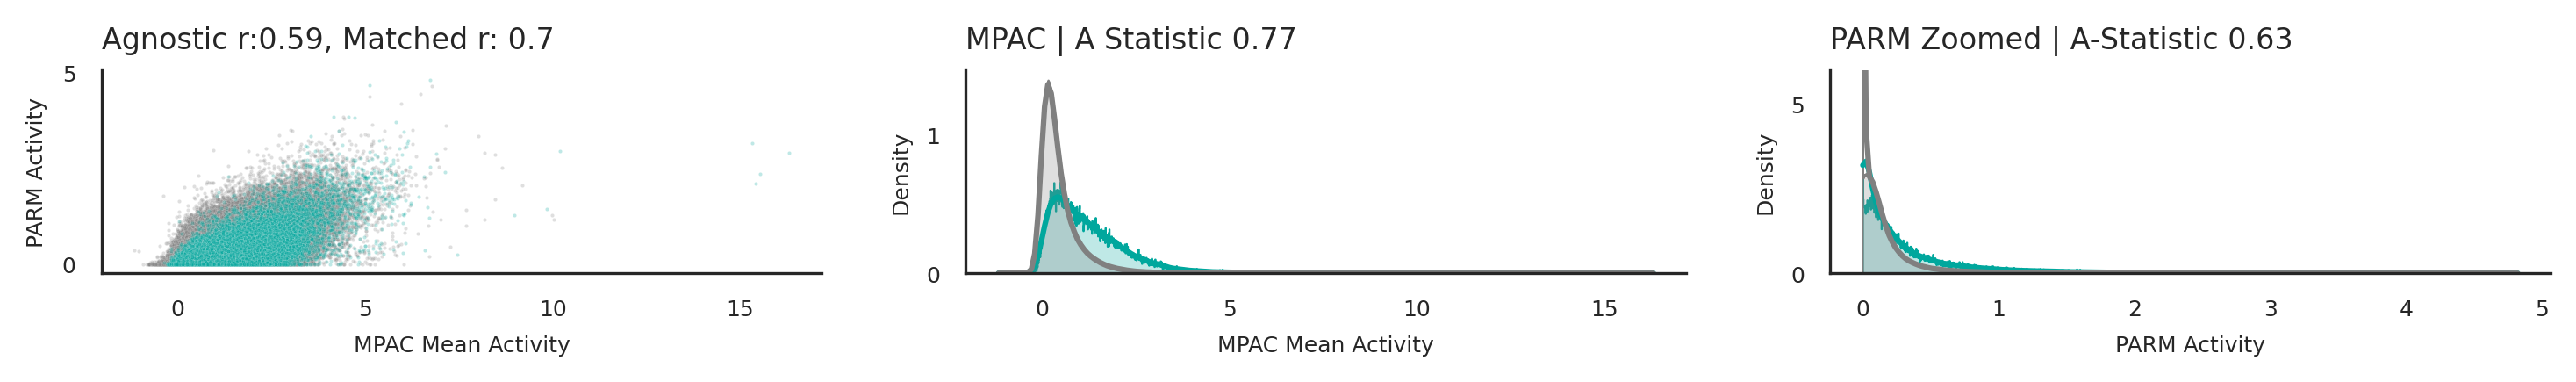

In [19]:
dELS_mpac_parm_summary(k562_merged_preds,
                      'K562',
                      '#00A79D',
                      'figures/mpac_vs_parm_activity_k562_zoomed.pdf')

28645
Sub-sampling full datasets down to 100000 rows each...
Running 5000 fast bootstrap iterations...


100%|██████████| 5000/5000 [03:42<00:00, 22.45it/s]


Bootstrap complete.

--- Results ---
Observed A-statistic (MPAC): 0.749
Observed A-statistic (PARM): 0.658
Observed Difference (MPAC - PARM): 0.092
95% Confidence Interval for the Difference: [0.088, 0.098]

Conclusion: The confidence interval does NOT contain 0.
This provides significant evidence that the effect sizes are different between the two models.


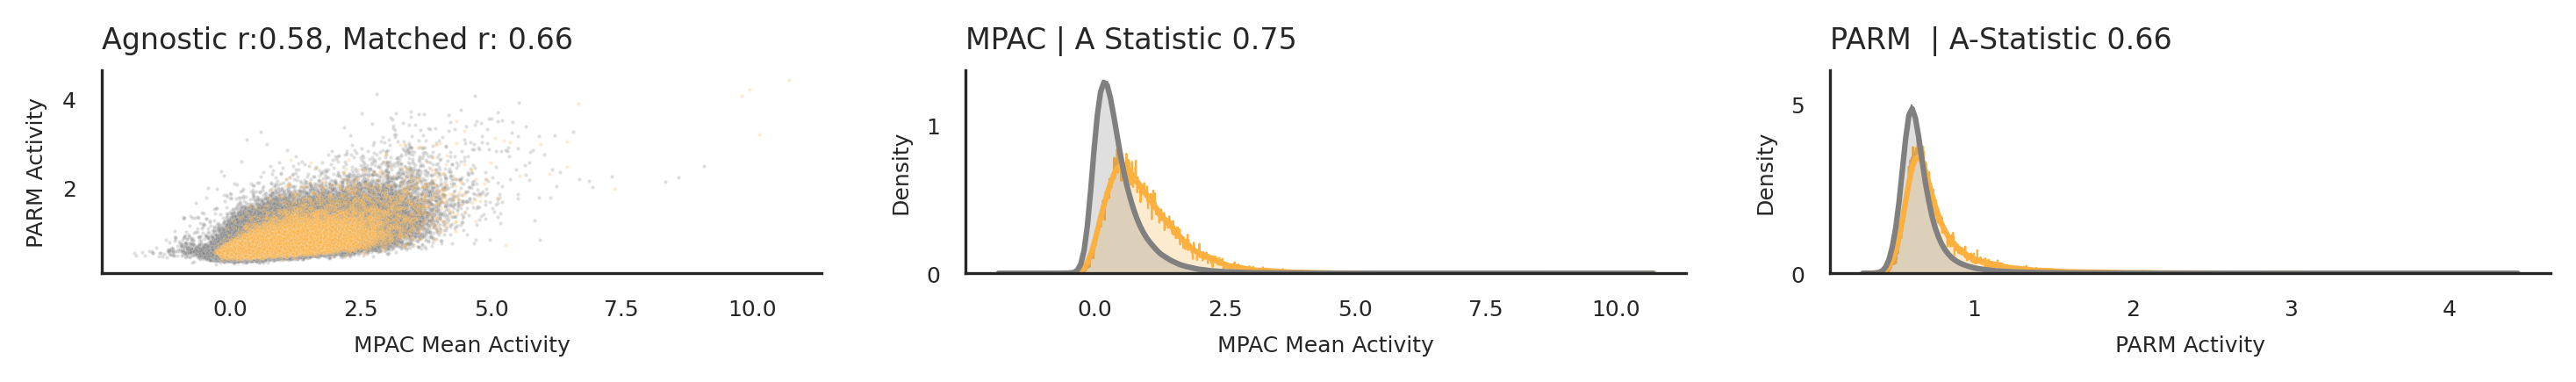

In [20]:
dELS_mpac_parm_summary(hepg2_merged_preds,
                      'HepG2',
                      '#FBB040',
                      'figures/mpac_vs_parm_activity_hepg2.pdf')

In [33]:
# calculate number of 0-predicted enahncers for both K562 matched and cell type agnostic dELS
# k specific
k_specific_dels = k562_merged_preds[k562_merged_preds['cCRE_type'] == 'cell_type_matched'].copy()
# get the proportion
print(f'parm predicts {len(k_specific_dels[k_specific_dels['prediction_K562'] == 0]) / len(k_specific_dels):.2}% of k562 matched enhancers to have 0 activity')
# cell type agnostic
k_agnostic_dels = k562_merged_preds[k562_merged_preds['cCRE_type'] == 'cell_type_agnostic'].copy()
# get the proportion
print(f'parm predicts {len(k_agnostic_dels[k_agnostic_dels['prediction_K562'] == 0]) / len(k_agnostic_dels):.2}% of agnostic enhancers to have 0 activity')


parm predicts 0.27% of k562 matched enhancers to have 0 activity
parm predicts 0.39% of agnostic enhancers to have 0 activity


In [27]:
k562_merged_preds.head()

,id,k562_ref_pred,sequence,header,prediction_K562,cCRE_type
0,EH38E0064571,1.066712,TACTGCTTTGTGCAAATGCAGCCGGGTTTATGATCAGGACTGCTCT...,chr1:1847160-1847451,0.098851,cell_type_agnostic
1,EH38E0065181,1.535866,AGACAGGGAGGCTGGAGGTACACAGGGCGGCATGAGAACCGAAGCC...,chr1:3159161-3159502,0.136758,cell_type_agnostic
2,EH38E0066213,0.524802,GGGAGCAAGAAGCTTTCTTTCATTACGGGCCACCAGCAGGGAAAAA...,chr1:5939829-5940062,0.000000,cell_type_agnostic
3,EH38E0068841,1.047862,TCTAAGCCTGTTACCTAATATCCTGCTACCTGTGTGTATAGCCTAC...,chr1:10151638-10151839,0.647575,cell_type_agnostic
4,EH38E0070245,0.330466,GCACCATTTCCTTGGTTCAGGCTCACCCAGTCACTGCCAGAGAGAC...,chr1:12601285-12601579,0.066439,cell_type_matched


In [15]:
# get the Z-Score of each prediction type to have the comparison #
# k562 mean ref prediction
# mpac_k_std = np.std(k562_merged_preds['k562_ref_pred'])
# mpac_k_mean = np.mean(k562_merged_preds['k562_ref_pred'])
# # calculate z-score
# k562_merged_preds.loc[:,'mpac_z_score'] = (k562_merged_preds['k562_ref_pred'] - mpac_k_mean) / mpac_k_std
# # parm k562
# parm_k_std = np.std(k562_merged_preds['prediction_K562'])
# parm_k_mean = np.mean(k562_merged_preds['prediction_K562'])
# # calculate z-score
# k562_merged_preds.loc[:,'parm_z_score'] = (k562_merged_preds['prediction_K562'] - parm_k_mean) / parm_k_mean